## Actividad 5
### Parte 1: Predicción de ventas usando regreión lineal múltiple

   year   make                model        trim   body transmission  \
0  2015    Kia              Sorento          LX    SUV    automatic   
1  2015    Kia              Sorento          LX    SUV    automatic   
2  2014    BMW             3 Series  328i SULEV  Sedan    automatic   
3  2015  Volvo                  S60          T5  Sedan    automatic   
4  2014    BMW  6 Series Gran Coupe        650i  Sedan    automatic   

                 vin state  condition  odometer  color interior  \
0  5xyktca69fg566472    ca        5.0   16639.0  white    black   
1  5xyktca69fg561319    ca        5.0    9393.0  white    beige   
2  wba3c1c51ek116351    ca       45.0    1331.0   gray    black   
3  yv1612tb4f1310987    ca       41.0   14282.0  white    black   
4  wba6b2c57ed129731    ca       43.0    2641.0   gray    black   

                                   seller      mmr  sellingprice  \
0                 kia motors america  inc  20500.0       21500.0   
1                 kia motors ameri

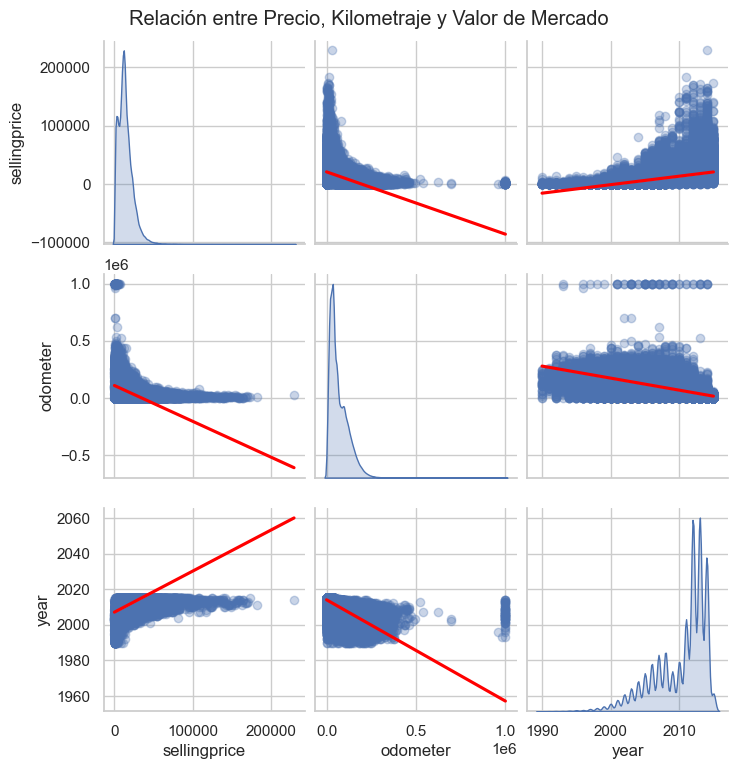

In [ ]:
import kagglehub
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split


# preparación de los datos
path = kagglehub.dataset_download("syedanwarafridi/vehicle-sales-data")

archivos = os.listdir(path)

archivoCvs = os.path.join(path, 'car_prices.csv') 
df = pd.read_csv(archivoCvs)

print(df.head())

#limpiar
print(df.isnull().sum())
dfClean = df.dropna()


#analisis exploratorio
#odometer es kilometraje

variableIntereses = ['sellingprice','odometer', 'year']
sns.set_theme(style="whitegrid")

grafico = sns.pairplot(dfClean[variableIntereses], kind='reg', diag_kind='kde', plot_kws={'line_kws':{'color':'red'}, 'scatter_kws': {'alpha': 0.3}})

plt.suptitle("Relación entre Precio, Kilometraje y Valor de Mercado", y=1.02)
plt.show()



In [ ]:
# identificacion de variables
y = dfClean['sellingprice']

X = dfClean[['odometer', 'mmr']]

print("Variable dependiente (Y): sellingprice")
print("Variables independientes (X):", X.columns.tolist())


Variable dependiente (Y): sellingprice
Variables independientes (X): ['odometer', 'mmr']


In [40]:
# division de datos
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(f"Entrenamiento: {X_train.shape[0]} filas")
print(f"Prueba:        {X_test.shape[0]} filas")

Entrenamiento: 377860 filas
Prueba:        94465 filas


In [ ]:
# Modelado
from sklearn.linear_model import LinearRegression
modelo = LinearRegression()
modelo.fit(X_train, y_train)

print("Intercepto:", round(modelo.intercept_, 2))
print("Coeficiente odometer:", round(modelo.coef_[0], 6))
print("Coeficiente year:",     round(modelo.coef_[1], 2))

Intercepto: 102.25
Coeficiente odometer: -0.001239
Coeficiente year: 0.99


In [ ]:
#evaluacion del modelo
from sklearn.metrics import r2_score, mean_squared_error


y_pred = modelo.predict(X_test)

#eror cuadratico medio
r2  = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"R²:   {r2:.4f}")
print(f"MSE:  {mse:,.2f}")
print(f"RMSE: {rmse:,.2f}")

R²:   0.9686
MSE:  2,851,214.75
RMSE: 1,688.55


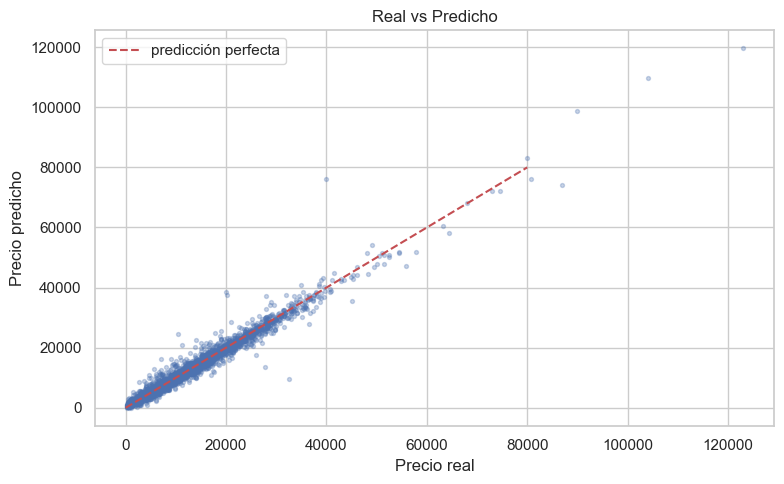

Precio estimado: $14,846.67


In [45]:
#prediccion

plt.figure(figsize=(8, 5))
plt.scatter(y_test[:3000], y_pred[:3000], alpha=0.3, s=8)
plt.plot([0, 80000], [0, 80000], 'r--', label='predicción perfecta')
plt.xlabel('Precio real')
plt.ylabel('Precio predicho')
plt.title('Real vs Predicho')
plt.legend()
plt.tight_layout()
plt.show()

nuevoDato = pd.DataFrame({'odometer': [60000], 'mmr': [15000]})
precioPredicho = modelo.predict(nuevoDato)
print(f"Precio estimado: ${precioPredicho[0]:,.2f}")

### Parte 2. Analísis de sobrevivencia en el Titanic con regresión logística binaria

In [117]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from scipy import stats

# prepariacion de datos
url = 'https://www.openml.org/data/get_csv/16826755/phpMYEkMl'
dfTitanic = pd.read_csv(url)

print(dfTitanic.head())
print("\nColumnas disponibles:", df.columns.tolist())
print("\nForma del dataset:", df.shape)

   pclass  survived                                             name     sex  \
0       1         1                    Allen, Miss. Elisabeth Walton  female   
1       1         1                   Allison, Master. Hudson Trevor    male   
2       1         0                     Allison, Miss. Helen Loraine  female   
3       1         0             Allison, Mr. Hudson Joshua Creighton    male   
4       1         0  Allison, Mrs. Hudson J C (Bessie Waldo Daniels)  female   

      age  sibsp  parch  ticket      fare    cabin embarked boat body  \
0      29      0      0   24160  211.3375       B5        S    2    ?   
1  0.9167      1      2  113781    151.55  C22 C26        S   11    ?   
2       2      1      2  113781    151.55  C22 C26        S    ?    ?   
3      30      1      2  113781    151.55  C22 C26        S    ?  135   
4      25      1      2  113781    151.55  C22 C26        S    ?    ?   

                         home.dest  
0                     St Louis, MO  
1  Mon

In [ ]:
#limpieza de datos
columnasEliminar = ['name', 'ticket', 'cabin', 'boat', 'body', 'home.dest']
dfCleanTitanic = dfTitanic.drop(columns=columnasEliminar)

print("Valores nulos:")
print(dfCleanTitanic.isnull().sum())

#conversion de variables
dfCleanTitanic['sex'] = dfCleanTitanic['sex'].map({'female': 1, 'male': 0})
dfCleanTitanic['age'] = pd.to_numeric(dfCleanTitanic['age'], errors='coerce')
dfCleanTitanic['fare'] = pd.to_numeric(dfCleanTitanic['fare'], errors='coerce')

dfCleanTitanic = dfCleanTitanic.dropna()
print(f"\nFilas restantes después de limpiar: {len(dfCleanTitanic)}")

dfCleanTitanic = dfCleanTitanic.dropna(subset=['survived', 'sex', 'age', 'fare', 'embarked', 'pclass'])

dfCleanTitanic['age'] = dfCleanTitanic['age'].astype(float)
print("Filas después de limpiar:", len(dfCleanTitanic))

Valores nulos:
pclass      0
survived    0
sex         0
age         0
sibsp       0
parch       0
fare        0
embarked    0
dtype: int64

Filas restantes después de limpiar: 1045
Filas después de limpiar: 1045


/var/folders/kv/3pgfrlds2p19zwg5r4fbdb3r0000gn/T/ipykernel_57025/1595278229.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=dfCleanTitanic, x='survived', y='fare', ax=axes[0,2],
/var/folders/kv/3pgfrlds2p19zwg5r4fbdb3r0000gn/T/ipykernel_57025/1595278229.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0,2].set_xticklabels(['No sobrevivió', 'Sobrevivió'])


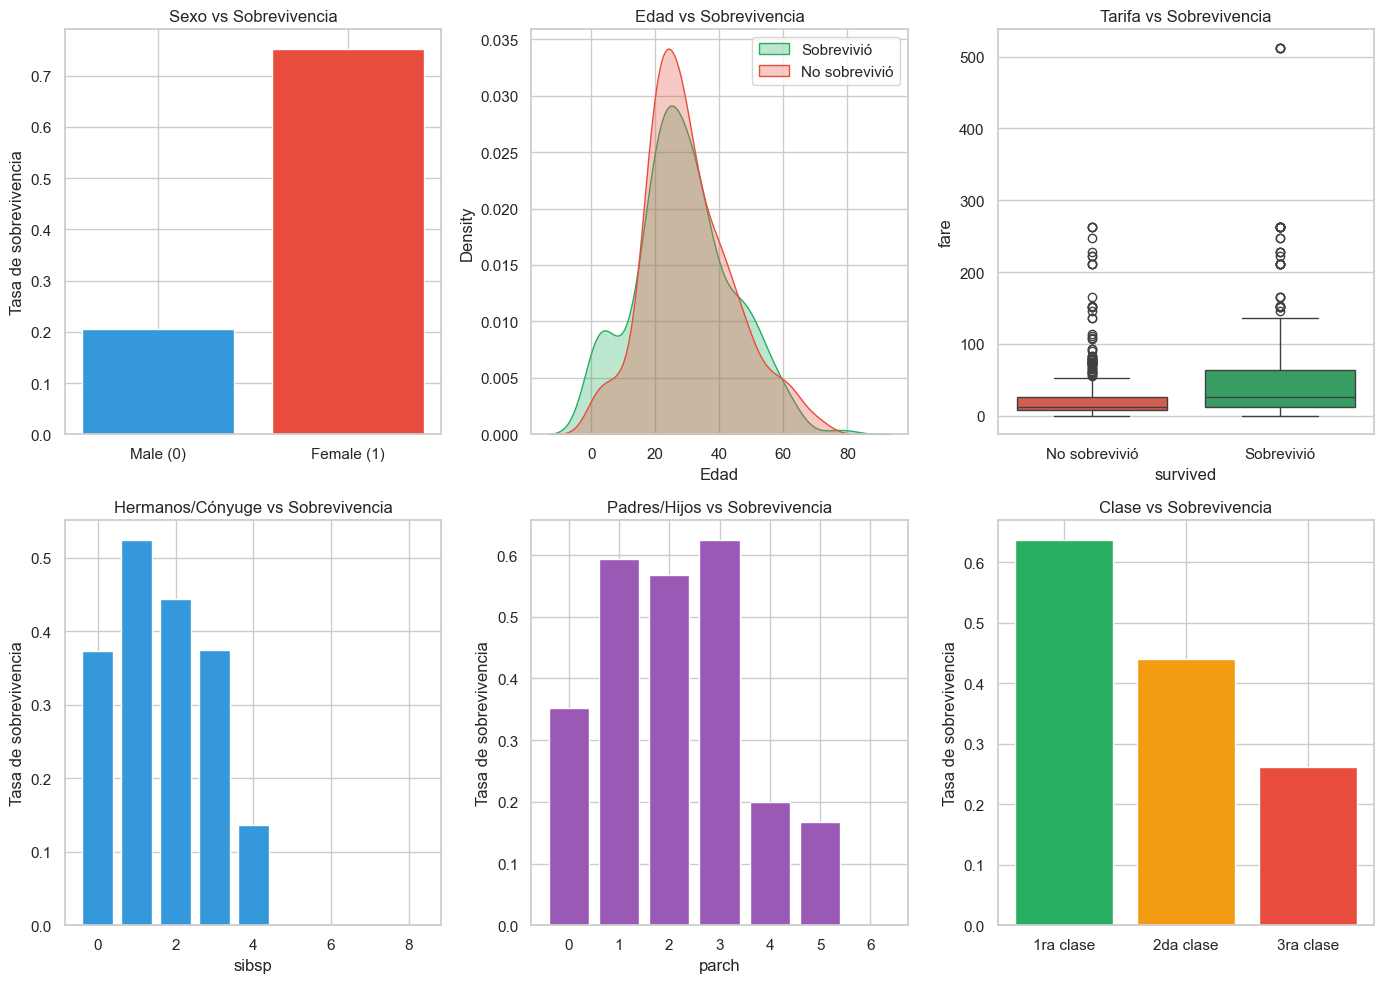

In [138]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 3, figsize=(14, 10))

# sex vs survived
tasaSexo = dfCleanTitanic.groupby('sex')['survived'].mean()
axes[0,0].bar(tasaSexo.index, tasaSexo.values, color=['#3498db', '#e74c3c'])
axes[0,0].set_title('Sexo vs Sobrevivencia')
axes[0,0].set_xticks([0, 1])
axes[0,0].set_xticklabels(['Male (0)', 'Female (1)'])
axes[0,0].set_ylabel('Tasa de sobrevivencia')

# age vs survived
sns.kdeplot(data=dfCleanTitanic[dfCleanTitanic['survived']==1], x='age',
            ax=axes[0,1], label='Sobrevivió', color='#27ae60', fill=True, alpha=0.3)
sns.kdeplot(data=dfCleanTitanic[dfCleanTitanic['survived']==0], x='age',
            ax=axes[0,1], label='No sobrevivió', color='#e74c3c', fill=True, alpha=0.3)
axes[0,1].set_title('Edad vs Sobrevivencia')
axes[0,1].set_xlabel('Edad')
axes[0,1].legend()

# fare vs survived
sns.boxplot(data=dfCleanTitanic, x='survived', y='fare', ax=axes[0,2],
            palette=['#e74c3c', '#27ae60'])
axes[0,2].set_title('Tarifa vs Sobrevivencia')
axes[0,2].set_xticklabels(['No sobrevivió', 'Sobrevivió'])

# sibsp vs survived
tasaSibsp = dfCleanTitanic.groupby('sibsp')['survived'].mean()
axes[1,0].bar(tasaSibsp.index, tasaSibsp.values, color='#3498db')
axes[1,0].set_title('Hermanos/Cónyuge vs Sobrevivencia')
axes[1,0].set_xlabel('sibsp')
axes[1,0].set_ylabel('Tasa de sobrevivencia')

# parch vs survived
tasaParch = dfCleanTitanic.groupby('parch')['survived'].mean()
axes[1,1].bar(tasaParch.index, tasaParch.values, color='#9b59b6')
axes[1,1].set_title('Padres/Hijos vs Sobrevivencia')
axes[1,1].set_xlabel('parch')
axes[1,1].set_ylabel('Tasa de sobrevivencia')

# clase vs survived
tasaClase = dfCleanTitanic.groupby('pclass')['survived'].mean()
axes[1,2].bar(tasaClase.index, tasaClase.values, color=['#27ae60', '#f39c12', '#e74c3c'])
axes[1,2].set_title('Clase vs Sobrevivencia')
axes[1,2].set_xticks([1, 2, 3])
axes[1,2].set_xticklabels(['1ra clase', '2da clase', '3ra clase'])
axes[1,2].set_ylabel('Tasa de sobrevivencia')

plt.tight_layout()
plt.show()

In [139]:
# Prueba t-test 
edadSobrevivio   = dfCleanTitanic[dfCleanTitanic['survived']==1]['age']
edadNoSobrevivio = dfCleanTitanic[dfCleanTitanic['survived']==0]['age']

tStat, pValue = stats.ttest_ind(edadSobrevivio, edadNoSobrevivio)

print("T-Test — Edad:")
print(f"  Media sobrevivió:    {edadSobrevivio.mean():.2f} años")
print(f"  Media no sobrevivió: {edadNoSobrevivio.mean():.2f} años")
print(f"  p-value: {pValue:.4f}")

if pValue < 0.05:
    print("  p < 0.05 → la edad SÍ es relevante para predecir sobrevivencia")
else:
    print("  p >= 0.05 → la edad NO es significativa")

tarifaSobrevivio   = dfCleanTitanic[dfCleanTitanic['survived']==1]['fare']
tarifaNoSobrevivio = dfCleanTitanic[dfCleanTitanic['survived']==0]['fare']

tStat2, pValue2 = stats.ttest_ind(tarifaSobrevivio, tarifaNoSobrevivio)

print("\nT-Test — Tarifa:")
print(f"  Media sobrevivió:    {tarifaSobrevivio.mean():.2f}")
print(f"  Media no sobrevivió: {tarifaNoSobrevivio.mean():.2f}")
print(f"  p-value: {pValue2:.4f}")

if pValue2 < 0.05:
    print("  p < 0.05 → la tarifa SÍ es relevante para predecir sobrevivencia")
else:
    print("  p >= 0.05 → la tarifa NO es significativa")

T-Test — Edad:
  Media sobrevivió:    28.92 años
  Media no sobrevivió: 30.50 años
  p-value: 0.0813
  p >= 0.05 → la edad NO es significativa

T-Test — Tarifa:
  Media sobrevivió:    53.38
  Media no sobrevivió: 25.15
  p-value: 0.0000
  p < 0.05 → la tarifa SÍ es relevante para predecir sobrevivencia


In [ ]:
# Division de datos

#variable dependiente
y = dfCleanTitanic['survived']

# variables independientes
X = dfCleanTitanic[['sex', 'age', 'fare', 'sibsp', 'parch']]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Entrenamiento: {X_train.shape[0]} pasajeros")
print(f"Prueba:        {X_test.shape[0]} pasajeros")
print(f"\nVariable dependiente: survived")
print(f"Variables independientes: {X.columns.tolist()}")

Entrenamiento: 836 pasajeros
Prueba:        209 pasajeros

Variable dependiente: survived
Variables independientes: ['sex', 'age', 'fare', 'sibsp', 'parch']


In [144]:
# creacion del modelo
modelo = LogisticRegression(max_iter=1000, random_state=42)
modelo.fit(X_train, y_train)


y_pred = modelo.predict(X_test)

print("Reporte de clasificación:")
print(classification_report(y_test, y_pred,
      target_names=['No sobrevivió', 'Sobrevivió']))


cm = confusion_matrix(y_test, y_pred)
print("Matriz de confusión:")
print(cm)

Reporte de clasificación:
               precision    recall  f1-score   support

No sobrevivió       0.74      0.77      0.75       120
   Sobrevivió       0.67      0.63      0.65        89

     accuracy                           0.71       209
    macro avg       0.70      0.70      0.70       209
 weighted avg       0.71      0.71      0.71       209

Matriz de confusión:
[[92 28]
 [33 56]]


In [145]:
# ceficientes y los odds ratio
coeficientes = pd.DataFrame({
    'variable':    X.columns,
    'coeficiente': modelo.coef_[0],
    'odds_ratio':  np.exp(modelo.coef_[0])
}).sort_values('odds_ratio', ascending=False).reset_index(drop=True)

print(coeficientes.to_string(index=False))

print("\nInterpretación:")
for _, row in coeficientes.iterrows():
    OR  = row['odds_ratio']
    var = row['variable']
    if OR > 1:
        print(f"  {var}: OR={OR:.3f} → aumenta probabilidad de sobrevivir")
    else:
        print(f"  {var}: OR={OR:.3f} → disminuye probabilidad de sobrevivir")

variable  coeficiente  odds_ratio
     sex     2.587147   13.291798
    fare     0.012229    1.012304
     age    -0.020025    0.980174
   parch    -0.075096    0.927654
   sibsp    -0.377281    0.685723

Interpretación:
  sex: OR=13.292 → aumenta probabilidad de sobrevivir
  fare: OR=1.012 → aumenta probabilidad de sobrevivir
  age: OR=0.980 → disminuye probabilidad de sobrevivir
  parch: OR=0.928 → disminuye probabilidad de sobrevivir
  sibsp: OR=0.686 → disminuye probabilidad de sobrevivir
